## Prueba de el data set

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [5]:
csa = pd.read_csv('customer-segmentation-analysis/data/raw/marketing_campaign.csv', sep='\t')
csa.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Interpratacion del Dataset
Denotamos que no tenemos una variable objetivo, es decir no hay una respuesta correcta predefinida. Tambien por la naturaleza del dataset deduimos que lo optimo en estos datos seria encontrar patrones ocultos y agrupar a los clientes similares para despues definir estrategias comerciales en base a esto. Por lo tanto utilizaremos Aprendizaje no supervisado y en una gran medida del porcentaje experimentaremos con tecnicas de clustering.

Una vez definido esto centrare el trabajo en la tecnica de clustering llamada K-means, ya que otros algorimos no tienen la ventaja unica de definir el numero de clusteres, y para este analisis necesitamos definir un grupo pequeño, ya que un numero grande de clusteres seria ineficiente para lo que intentamos.

## Verificacion de Nulos

In [ ]:
# Conteo de los nulos y filtro de las columnas que tienen un valor mayor a 0
conteo_nulos = csa.isnull().sum()
columnas_con_nulos = conteo_nulos[conteo_nulos > 0]

print("Conteo de valores nulos por columna:")
print(conteo_nulos)




Conteo de valores nulos por columna:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


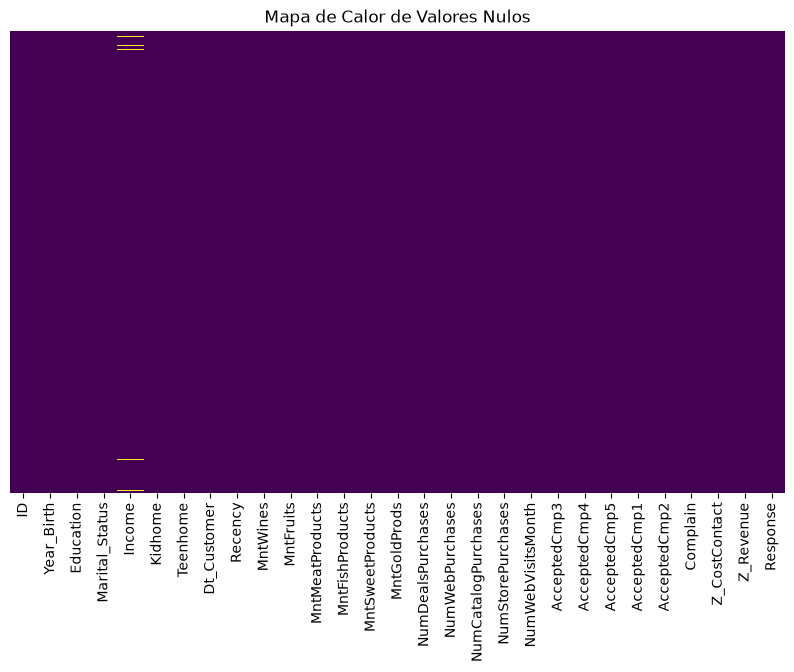

In [15]:


plt.figure(figsize=(10, 6))
# Crea un mapa de calor donde las franjas amarillas representan los valores nulos
sns.heatmap(csa.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Mapa de Calor de Valores Nulos")
plt.show()

## Investigacion de Variables

### Nuevas Variables

1. Tenemos una Variable de año de nacimiento, la cual es problematica y funciona mejor si directamente la convertimos a Edad.
2. Tenemos 6 variables las cuales nos ayudan a ver cuanto a gastado el cliente en distintos productos, para terminos de eficiencia nos ayuda mas ver cuanto vale el cliente en general o cuanto a gastado este en total. Entonces estas variables se convertiran en una sola de "Total".
3. Tenemos dos variables (kidhome y teenhome) que nos ayudan a ver cuantas personas viven con el usuario, pero son poco eficientes y no significan nada al tenerlas separadas.
4. Tenemos Marital_Status que es funcional para la lectura, pero no para un modelo de IA, este campo lo simplificamos en uno binario.

### Variables "Ruido"

Hay algunas avriables que aportan lo mismo que otras, lo que causa multicolinealidad, entonces estan las descartamos.
Borramos Year_Birth, Marital_Status, Kidhome y Teenhome.

Tambien tenemos dos variables que presentan un problema de varianza cero, estas variables (Z_CostContact con 3 y Z_Revenue con 11) tienen el mismo valor en todas sus filas.
Borramos Z_CostContact y Z_Revenue.


## Deteccion de valores Atipicos
Para detectar valores atípicos, usamos un boxplot para cada columna numérica. Esto nos permitirá visualizar la distribución de los datos y detectar posibles outliers.

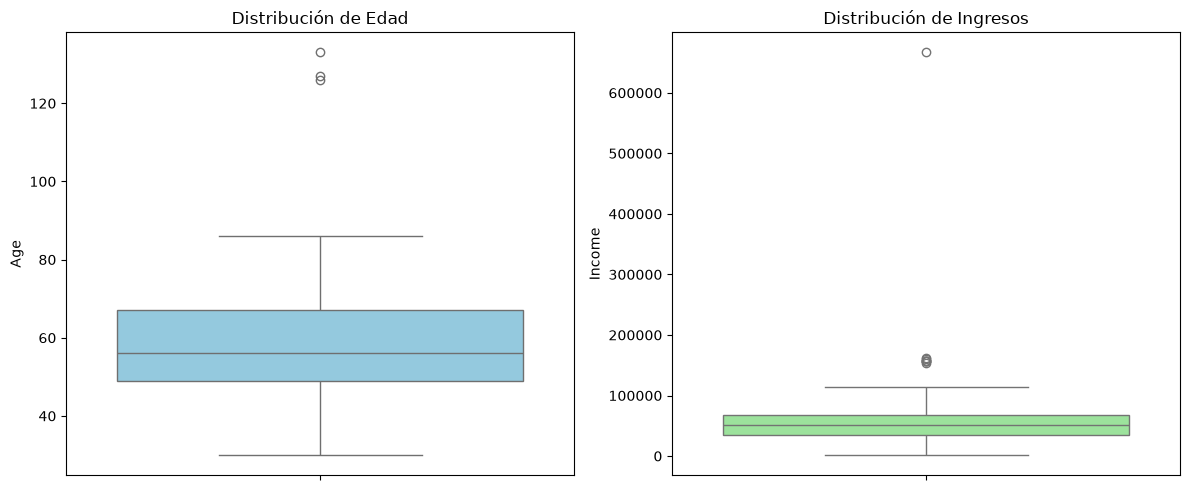

In [ ]:
plt.figure(figsize=(12, 5))
csa['Age'] = 2026 - csa['Year_Birth']
# Gráfico para la Edad
plt.subplot(1, 2, 1)
sns.boxplot(y=csa['Age'], color='skyblue')
plt.title('Distribución de Edad')

# Gráfico para los Ingresos
plt.subplot(1, 2, 2)
sns.boxplot(y=csa['Income'], color='lightgreen')
plt.title('Distribución de Ingresos')

plt.tight_layout()
plt.show()

#Solamente estan las columnas que encontramos relevantes para el análisis y eliminamos las demás.

## Estandarizacion de los datos
Para acompañar y optimizar el algoritmo seleccionado (K-means) necesitamos transaformar los datos para que estos puedan ser consumidos facilmente.
Lo que hacemos con StandardScaler es usar la estandarizacion Z-Score, loq eu hace que nuestros datos tengan una media = 0 y una desviacion estandar = 1, convirtiendo las variables en unidades de varianza pura.
Seleccione este metodo ya que otros metodos como Min-Max podrian presentar un riesgo y aplastar los valores en rangos diminutos fallando en el objetivo.